In [ ]:
#Marshall Scott
#Executive producrs erdos project fall 2026
#EDA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import cpi
import re
import ast
warnings.filterwarnings('ignore')

import sklearn.utils


pd.options.display.max_columns = None


df_ini = pd.read_csv('/home/mars/exec-prod/final_dataset.csv')
df_ini.head(10)


,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,directors,stars,budget,opening_weekend_gross,gross_worldwide,gross_us_canada,release_date,countries_origin,filming_locations,production_companies,awards_content,genres,languages
0,tt0027483,The Crimson Circle,1h 16m,NaN,6.4,30,NaN,An extortion ring murders anyone who refuses t...,https://www.imdb.com/title/tt0027483/,"['Reginald Denham', 'Edgar Wallace', 'Howard I...",['Reginald Denham'],"['Hugh Wakefield', 'Alfred Drayton', 'Niall Ma...",NaN,NaN,NaN,NaN,1936-08-10,['United Kingdom'],NaN,['Richard Wainwright Productions'],NaN,['Drama'],['English']
1,tt0058131,The Mystery of Thug Island,1h 36m,NaN,5.0,114,NaN,"Three year old Ada, daughter of the British ca...",https://www.imdb.com/title/tt0058131/,"['Emilio Salgari', 'Arpad DeRiso', 'Ottavio Po...",['Luigi Capuano'],"['Guy Madison', 'Ingeborg Schöner', 'Giacomo R...",NaN,NaN,NaN,NaN,1966-05-28,"['Italy', 'Monaco', 'West Germany']",NaN,"['Eichberg-Film', 'Liber Film']",NaN,['Adventure'],['Italian']
2,tt0042760,Las mujeres de mi general,1h 52m,Not Rated,6.8,74,NaN,Infante stars as a rebel general caught up in ...,https://www.imdb.com/title/tt0042760/,"['Joselito Rodríguez', 'Celestino Gorostiza', ...",['Ismael Rodríguez'],"['Pedro Infante', 'Lilia Prado', 'Chula Prieto...",NaN,NaN,NaN,NaN,1951-07-13,['Mexico'],NaN,['Producciones Rodríguez Hermanos'],NaN,"['Drama', 'War']",['Spanish']
3,tt0027667,Gentle Julia,1h 2m,Approved,6.8,38,NaN,A shy newspaperman (Brown) nearly gives up whe...,https://www.imdb.com/title/tt0027667/,"['Booth Tarkington', 'Lamar Trotti']",['John G. Blystone'],"['Jane Withers', 'Tom Brown', 'Marsha Hunt', '...",NaN,NaN,NaN,NaN,1936-04-10,['United States'],"['20th Century Fox Studios - 10201 Pico Blvd.,...",['Twentieth Century Fox'],NaN,"['Comedy', 'Drama', 'Romance']",['English']
4,tt0055747,Love at Twenty,1h 50m,NaN,7.2,2.5K,NaN,"""Love at Twenty"" unites five directors from ar...",https://www.imdb.com/title/tt0055747/,"['Shintarô Ishihara', 'Marcel Ophüls', 'Renzo ...","['Shintarô Ishihara', 'Marcel Ophüls', 'Renzo ...","['Jean-Pierre Léaud', 'Marie-France Pisier', '...",NaN,NaN,NaN,NaN,1963-02-06,"['France', 'Italy', 'Japan', 'Poland', 'West G...","['Warsaw Zoo, Ratuszowa, Praga Pólnoc, Warsaw,...","['Ulysse Productions', 'Unitec Films', 'Cinese...",NaN,"['Drama', 'Romance']","['French', 'Polish', 'Japanese', 'Italian', 'G..."
5,tt0062768,Bye Bye Braverman,1h 34m,Approved,5.6,887,NaN,Four Jewish intellectuals carpool to the funer...,https://www.imdb.com/title/tt0062768/,"['Wallace Markfield', 'Herbert Sargent']",['Sidney Lumet'],"['George Segal', 'Jack Warden', 'Joseph Wisema...",NaN,NaN,NaN,NaN,1968-02-21,['United States'],"['Christopher Park, Manhattan, New York City, ...",['Warner Bros./Seven Arts'],NaN,"['Dark Comedy', 'Comedy', 'Drama']","['English', 'Hebrew']"
6,tt0041635,The cheat,1h 31m,NaN,7.2,478,NaN,After spending all his money to fulfill the sm...,https://www.imdb.com/title/tt0041635/,['Jacques Sigurd'],['Yves Allégret'],"['Bernard Blier', 'Simone Signoret', 'Jacques ...",NaN,NaN,NaN,NaN,1949-07-26,['France'],NaN,"['DisCina', 'Les Films Modernes (I)']",NaN,['Drama'],['French']
7,tt0014515,Strangers of the Night,1h 20m,NaN,5.0,13,NaN,"A rousing fusion of satire, mystery and action...",https://www.imdb.com/title/tt0014515/,"['Lenore J. Coffee', 'Walter C. Hackett', 'Ren...",['Fred Niblo'],"['Matt Moore', 'Enid Bennett', 'Barbara La Mar...",NaN,NaN,NaN,"$206,200",1923-09-10,['United States'],NaN,['Louis B. Mayer Productions'],NaN,"['Comedy', 'Mystery']","['None', 'English']"
8,tt0035248,Rembrandt,1h 39m,NaN,5.1,54,NaN,NaN,https://www.imdb.com/title/tt0035248/,"['Kurt Heuser', 'Hans Steinhoff', 'V. Tornius']",['Hans Steinhoff'],"['Ewald Balser', 'Hertha Feiler', 'Gisela Uhle...",NaN,NaN,NaN,NaN,1942-06-17,['Germany'],"['Amsterdam, Noord-Holland, Netherlands']",['Terra-Filmkunst'],NaN,"['Biography', 'Drama']",['German']
9,tt0889588,The Children of Huang Shi,2h 5m,R,7.0,10K,4

In [2]:
df_ini.info()

<class 'pandas.DataFrame'>
RangeIndex: 63249 entries, 0 to 63248
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     63249 non-null  str    
 1   title                  63249 non-null  str    
 2   duration               61174 non-null  str    
 3   mpa                    41227 non-null  str    
 4   rating                 59181 non-null  float64
 5   votes                  59181 non-null  str    
 6   méta_score             15533 non-null  float64
 7   description            60889 non-null  str    
 8   movie_link             63249 non-null  str    
 9   writers                62980 non-null  str    
 10  directors              63198 non-null  str    
 11  stars                  62905 non-null  str    
 12  budget                 15359 non-null  str    
 13  opening_weekend_gross  16837 non-null  str    
 14  gross_worldwide        20722 non-null  str    
 15  gross_us_cana

In [ ]:
#1/3 of data doesnt have worldwide gross
df_cut = df_ini[df_ini.gross_worldwide.notna()]
df_cut.head(10)

,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,directors,stars,budget,opening_weekend_gross,gross_worldwide,gross_us_canada,release_date,countries_origin,filming_locations,production_companies,awards_content,genres,languages
9,tt0889588,The Children of Huang Shi,2h 5m,R,7.0,10K,49.0,"About young British journalist, George Hogg, w...",https://www.imdb.com/title/tt0889588/,"['Jane Hawksley', 'James MacManus', 'Simon van...",['Roger Spottiswoode'],"['Jonathan Rhys Meyers', 'Radha Mitchell', 'Ch...","$40,000,000 (estimated)","$42,755","$7,785,975","$1,031,872",2008-06-13,"['Australia', 'China', 'Germany', 'United Stat...","['Xiandu, Zhejiang, China']","['Australian Film Finance Corporation (AFFC)',...",NaN,"['Drama', 'War']","['English', 'Japanese', 'Mandarin']"
13,tt9104622,Mirando Al Cielo,2h 2m,NaN,7.3,53,NaN,Difficult times and persecution in Mexico duri...,https://www.imdb.com/title/tt9104622/,['Antonio Peláez'],['Antonio Peláez'],"['Julián Fidalgo', 'Luis Xavier', 'Estela Cano...",NaN,NaN,"$626,319","$295,539",2023-05-10,['Mexico'],"['Arandas, Jalisco, Mexico (Hacienda el Manant...",['Mediaquest'],NaN,['Drama'],['Spanish']
16,tt6859352,Support the Girls,1h 33m,R,6.4,8.6K,85.0,The general manager at a highway-side ''sports...,https://www.imdb.com/title/tt6859352/,['Andrew Bujalski'],['Andrew Bujalski'],"['Regina Hall', 'Haley Lu Richardson', 'Dylan ...",NaN,"$51,167","$139,550","$129,124",2018-08-24,['United States'],"['Austin Texas, USA']","['Burn Later Productions', 'Houston King Produ...",NaN,"['Comedy', 'Drama']",['English']
19,tt0342300,Dopamine,1h 19m,R,5.9,1.2K,52.0,A San Franciscan computer programmer falls in ...,https://www.imdb.com/title/tt0342300/,"['Mark Decena', 'Timothy Breitbach']",['Mark Decena'],"['John Livingston', 'Sabrina Lloyd', 'Bruno Ca...",NaN,"$22,278","$69,544","$69,544",2003-01-23,['United States'],"['Bay Area, San Francisco, California, USA']",['Kontent Films'],NaN,"['Comedy', 'Drama', 'Romance']",['English']
20,tt3729920,The Disappearance of Eleanor Rigby: Them,2h 3m,R,6.3,13K,57.0,One couple's story as they try to reclaim the ...,https://www.imdb.com/title/tt3729920/,['Ned Benson'],['Ned Benson'],"['James McAvoy', 'Jessica Chastain', 'Viola Da...","$3,000,000 (estimated)","$66,941","$1,448,076","$587,774",2014-09-12,['United States'],"['New York City, New York, USA']","['Unison Films', 'Kim and Jim Productions', 'D...",NaN,"['Drama', 'Romance']","['English', 'French']"
25,tt4169250,M.S. Dhoni: The Untold Story,3h 4m,Not Rated,8.0,71K,NaN,The untold story of Mahendra Singh Dhoni's jou...,https://www.imdb.com/title/tt4169250/,"['Neeraj Pandey', 'Dilip Jha', 'Shyam Maheshwa...","['Mathur Goswami', 'Neeraj Pandey']","['Sushant Singh Rajput', 'Kiara Advani', 'Dish...",NaN,"$1,108,650","$28,903,047","$1,801,550",2016-09-30,['India'],"['Jamshedpur, Jharkhand, India']","['Adarsh Telemedia', 'Fox STAR Studios', 'Frid...",NaN,"['Biography', 'Drama', 'Sport']",['Hindi']
28,tt0838233,A Thousand Years of Good Prayers,1h 23m,Unrated,6.7,1.2K,64.0,A Chinese man travels to America to visit his ...,https://www.imdb.com/title/tt0838233/,['Yiyun Li'],['Wayne Wang'],"['Henry O', 'Pasha D. Lychnikoff', 'Feihong Yu...",NaN,"$10,321","$1,665,585","$76,806",2008-04-10,['United States'],"[""Coeur d'Alene, Idaho, USA""]","['Boram Entertainment', 'Entertainment Farm (E...",NaN,['Drama'],"['English', 'Mandarin', 'Persian']"
33,tt0209077,Ken Park,1h 33m,Not Rated,5.8,31K,NaN,Ken Park is about several Californian skateboa...,https://www.imdb.com/title/tt0209077/,"['Harmony Korine', 'Larry Clark']","['Larry Clark', 'Edward Lachman']","['Adam Chubbuck', 'James Bullard', 'Seth Gray'...",NaN,NaN,"$1,058,905",NaN,2003-04-03,"['United States', 'Netherlands', 'France']","['Visalia, California, USA']","['Cinéa', 'Kasander Film Company', 'Lou Yi Inc.']",NaN,['Drama'],['English']
34,tt10713340,Held,1h 34m,NaN,5.3,3.1K,46.0,A couple's ailing marriage is put to the test ...,https://www.imdb.com/title/tt107

In [13]:
import pandas as pd

url = 'https://github.com/tjwaterman99/boxofficemojo-scraper/releases/latest/download/revenues_per_day.csv.gz'
df = pd.read_csv(url, parse_dates=['date'], index_col='id')
df.head()

,date,title,revenue,theaters,distributor
id,,,,,
eb15a487-64a3-a1c1-d965-0697c580217b,2009-02-18,Confessions of a Shopaholic,862218,2507.0,Walt Disney Studios Motion Pictures
3c001b08-9710-c2a1-0178-8172ec084a0f,2009-02-18,Paul Blart: Mall Cop,604490,2965.0,Sony Pictures Entertainment (SPE)
e5a1e4fa-b1cb-a29d-bba2-83dfd7b4e6b0,2009-02-18,The International,575564,2364.0,Sony Pictures Entertainment (SPE)
c50b29e2-7aa9-8f35-54cb-963c34712a69,2009-02-18,Slumdog Millionaire,569061,1634.0,Fox Searchlight Pictures
289b16c9-3132-6b32-b1c9-895bd806a51c,2009-02-18,The Pink Panther 2,475113,3245.0,Sony Pictures Entertainment (SPE)


In [26]:
# Sort by date first if chronology matters, then take the top 5 per movie
top_titles = df.groupby('title')['revenue'].sum().nlargest(30)

In [27]:
top_titles.head(30)

title
Star Wars: Episode VII - The Force Awakens       935644139
Avengers: Endgame                                858373000
Spider-Man: No Way Home                          804059711
Avatar                                           749766139
Top Gun: Maverick                                716981130
Black Panther                                    700059566
Avatar: The Way of Water                         683183390
Avengers: Infinity War                           678815482
Jurassic World                                   652197981
Inside Out 2                                     650924793
Barbie                                           636837343
Deadpool & Wolverine                             635311148
Star Wars: Episode VIII - The Last Jedi          620181382
The Avengers                                     619257177
Incredibles 2                                    608581744
The Super Mario Bros. Movie                      574751990
The Lion King                                    5

In [34]:
top_titles.shape

(30,)

In [48]:
col_1 = df_ini[pd.to_datetime(df_ini.release_date).dt.year > 1999].title
col_2 = df.title.unique()

In [49]:
len(col_1), len(col_2)

(16049, 7176)

In [51]:
type(col_2)
l1 = list(col_1)
l2 = list(col_2)


In [52]:
l3 = list(set(l1) - set(l2))
len(l3)

9350

In [54]:
df_cut.columns

Index(['id', 'title', 'duration', 'mpa', 'rating', 'votes', 'méta_score',
       'description', 'movie_link', 'writers', 'directors', 'stars', 'budget',
       'opening_weekend_gross', 'gross_worldwide', 'gross_us_canada',
       'release_date', 'countries_origin', 'filming_locations',
       'production_companies', 'awards_content', 'genres', 'languages'],
      dtype='str')

In [36]:
cl = ['title', 'duration', 'mpa',
       'description', 'writers', 'directors', 'stars', 'budget',
       'opening_weekend_gross', 'gross_worldwide', 'gross_us_canada',
       'release_date', 'countries_origin', 'production_companies', 'genres', 'languages']

In [37]:
def getLength(val):
    if pd.isna(val):
        return 0.0

    # Convert to string just in case it's stored as a number
    val = str(val)
    v = val.split()

    hrs = 0.0
    mns = 0.0

    for part in v:
        if 'h' in part:
            hrs = float(part.replace('h', ''))
        elif 'm' in part:
            mns = float(part.replace('m', ''))

    return 60 * hrs + mns

In [38]:
def getGenre(gen):
    if pd.isna(gen):
        s = set('None')
        return s
    s = set(gen)
    return s


In [39]:
import ast
gset = set()

for x in df_cut.genres:
    if pd.isna(x): 
        gset.update('X')
        continue
    genre_list = ast.literal_eval(x) if isinstance(x, str) else x
    gset.update(genre_list)

In [40]:
gdict = {}
for ele in gset:
    gdict[ele] = 0.0

In [41]:
for x in df_cut.genres:
    if pd.isna(x): 
        gdict['X'] = gdict['X'] + 1
        continue
    genre_list = ast.literal_eval(x) if isinstance(x, str) else x
    for ele in genre_list:
        gdict[ele] = gdict[ele] + 1.0 / len(genre_list)

In [42]:

def correctForInflationBudget(row):
    year = pd.to_datetime(row['release_date']).year
    cost = row['budget']
    if pd.isna(cost) or '$' not in cost:
        cost = 1
    else:
        cost = re.sub(r'\D', '', cost)
        
    return cpi.inflate(float(cost), year, 2025)

def correctForInflationGross(row):
    year = pd.to_datetime(row['release_date']).year
    cost = row['gross_worldwide']
    if pd.isna(cost) or '$' not in cost:
        cost = 1
    else:
        cost = re.sub(r'\D', '', cost)
        
    return cpi.inflate(float(cost), year, 2025)
 

In [43]:
df_cut['duration'] = df_cut.duration.map(getLength)
df_cut['budget_cpi'] = df_cut.apply(correctForInflationBudget, axis=1)
df_cut['gross_cpi'] = df_cut.apply(correctForInflationGross, axis=1)

In [ ]:
#Half of entries dont have budgets
len(df_cut[pd.isna(df_cut.budget)]) / len(df_cut)

0.4974905897114178

<Axes: xlabel='Count', ylabel='gross_cpi'>

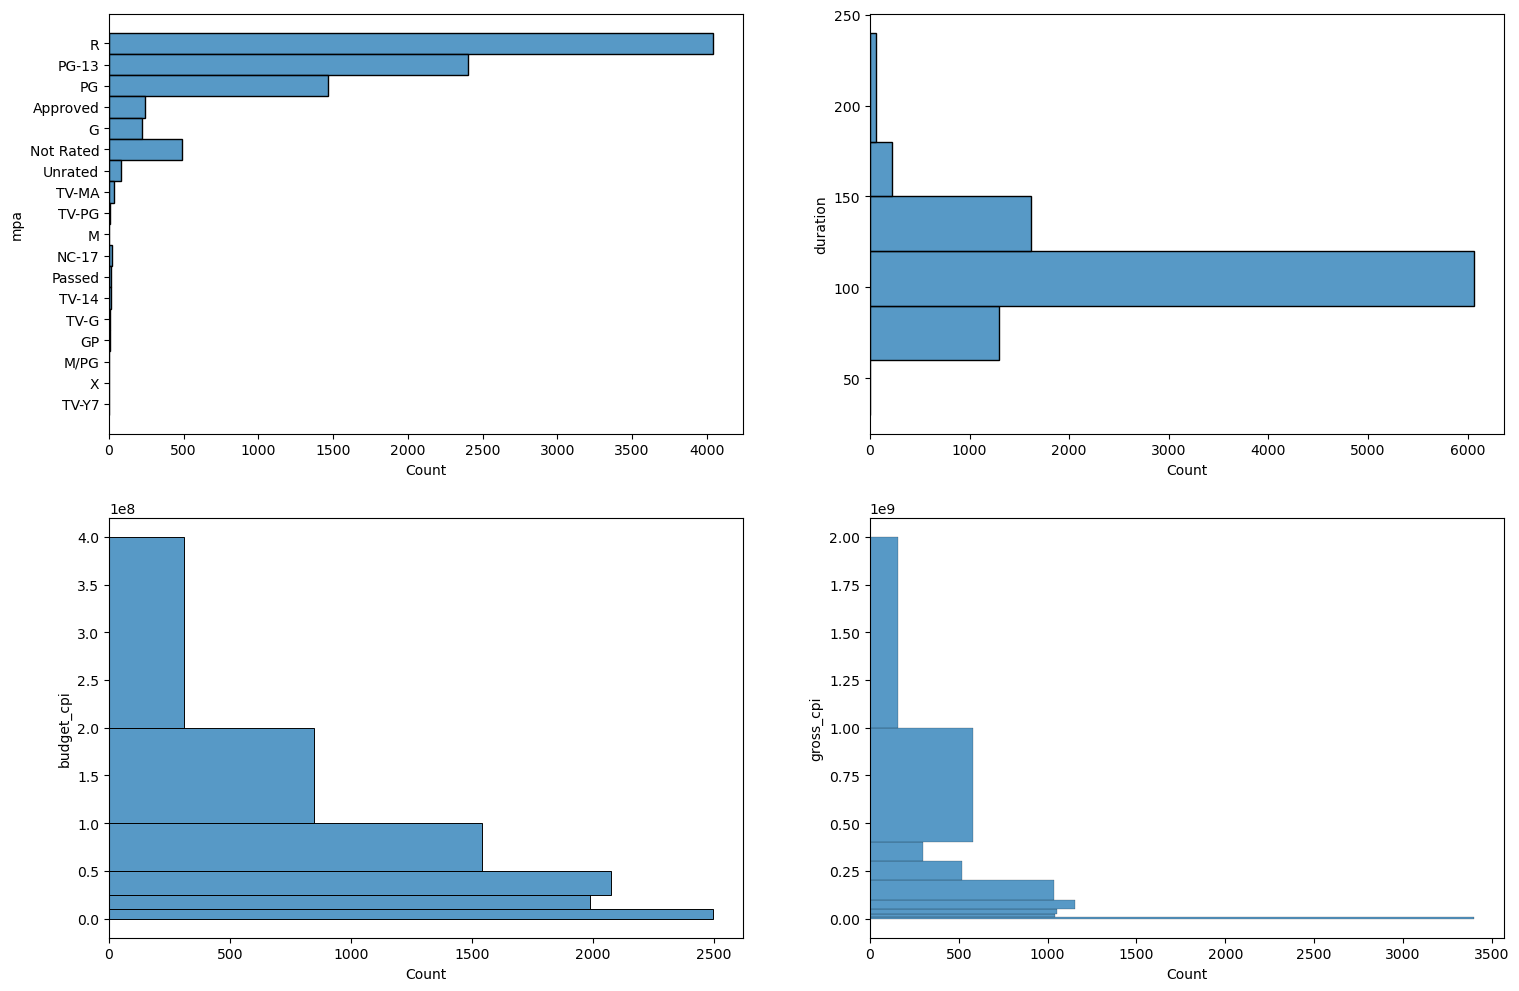

In [44]:

fig, axs = plt.subplots(ncols=2,nrows=2, figsize=(18, 12))
sns.histplot(y=df_cut[df_cut.budget_cpi > 1000].mpa, ax=axs[0,0])
sns.histplot(y=df_cut[df_cut.budget_cpi > 1000].duration, ax=axs[0,1],bins=[30,60,90,120, 150,180,240])
sns.histplot(y=df_cut[df_cut.budget_cpi > 1000].budget_cpi, ax=axs[1,0], bins=[0, 1e7, 2.5e7,5e7,1e8,2e8,4e8])
sns.histplot(y=df_cut[df_cut.budget_cpi > 1000].gross_cpi, ax=axs[1,1], bins=[0, 1e7, 2.5e7,5e7,1e8,2e8,3e8,4e8,1e9,2e9])


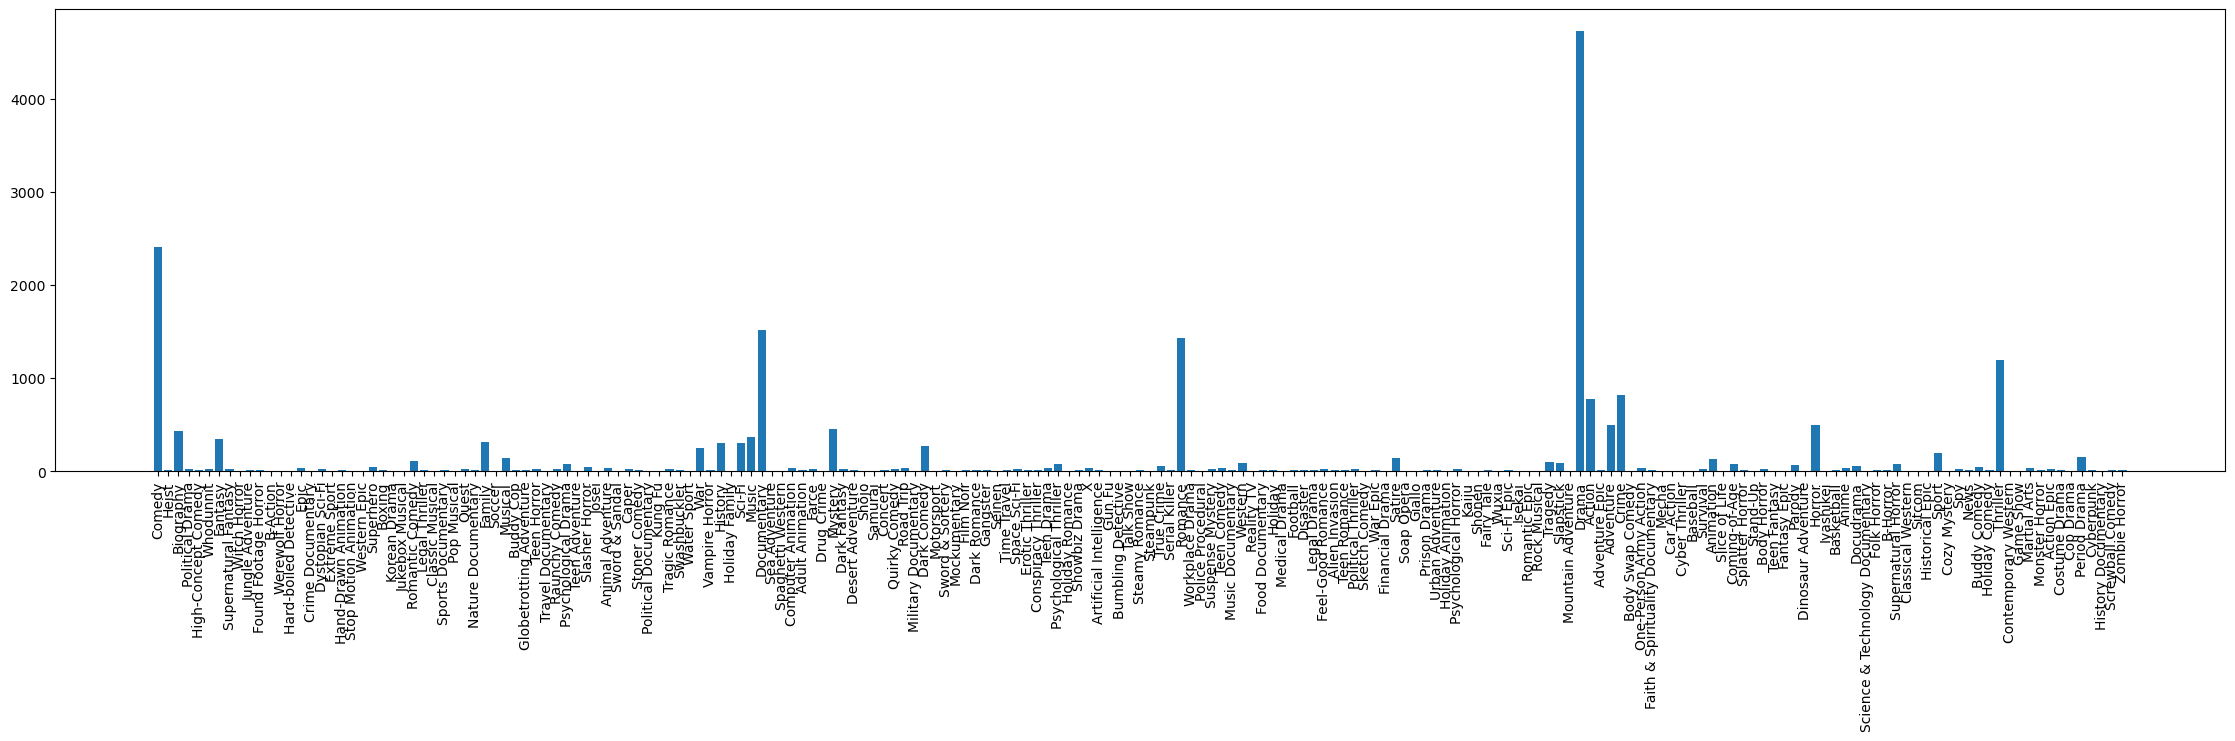

In [ ]:
fig, ax = plt.subplots(figsize=(28,6))

plt.bar(x=gdict.keys(), height = gdict.values(), )
ax.tick_params(axis='x', rotation=90)

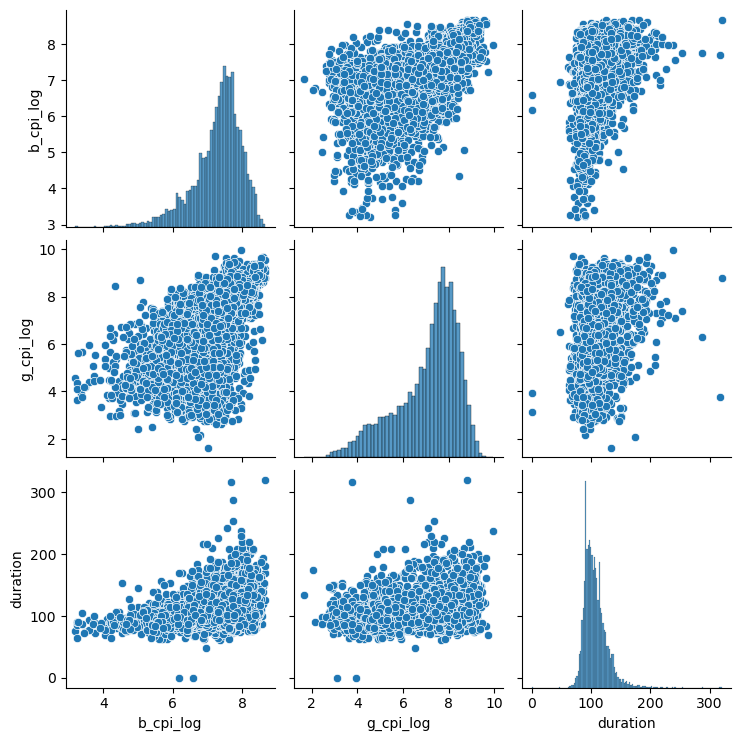

In [45]:
ll = ['mpa','b_cpi_log','g_cpi_log', 'duration']
df_cut['b_cpi_log'] = np.log10(df_cut['budget_cpi'])
df_cut['g_cpi_log'] = np.log10(df_cut['gross_cpi'])

sns.pairplot(df_cut.loc[df_cut['budget_cpi'] > 1000,ll])

In [90]:
def grossSplit(df,col):
    gset = set()
    gdict = {}
    adict = {}
    for x in df[col]:
        if pd.isna(x): 
            gset.update('X')
            continue
        list = ast.literal_eval(x) if isinstance(x, str) else x
        gset.update(list)
    
    for ele in gset:
        gdict[ele] = 0.0
        adict[ele] = 0.0

    for i, row  in df.iterrows():
        x = row[col]
        if pd.isna(x): 
            gdict['X'] = gdict['X'] + 1
            adict['X'] = adict['X'] + 1
            continue
        list = ast.literal_eval(x) if isinstance(x, str) else x
        for ele in list:
            gdict[ele] = gdict[ele] + row['gross_cpi'] / len(list)
            adict[ele] = adict[ele] + 1.0
    return gset, gdict, adict

In [91]:
wset, wdict, wad = grossSplit(df_cut, 'writers')
rset, rdict, rad = grossSplit(df_cut, 'directors')
sset, sdict, sad = grossSplit(df_cut, 'stars')
pset, pdict, pad = grossSplit(df_cut, 'production_companies')
gset, gdict, gad = grossSplit(df_cut, 'genres')

In [72]:
len(wset), len(rset), len(sset), len(pset), len(gset)

(23458, 10904, 95321, 18314, 193)

Text(0.5, 1.0, 'Genres')

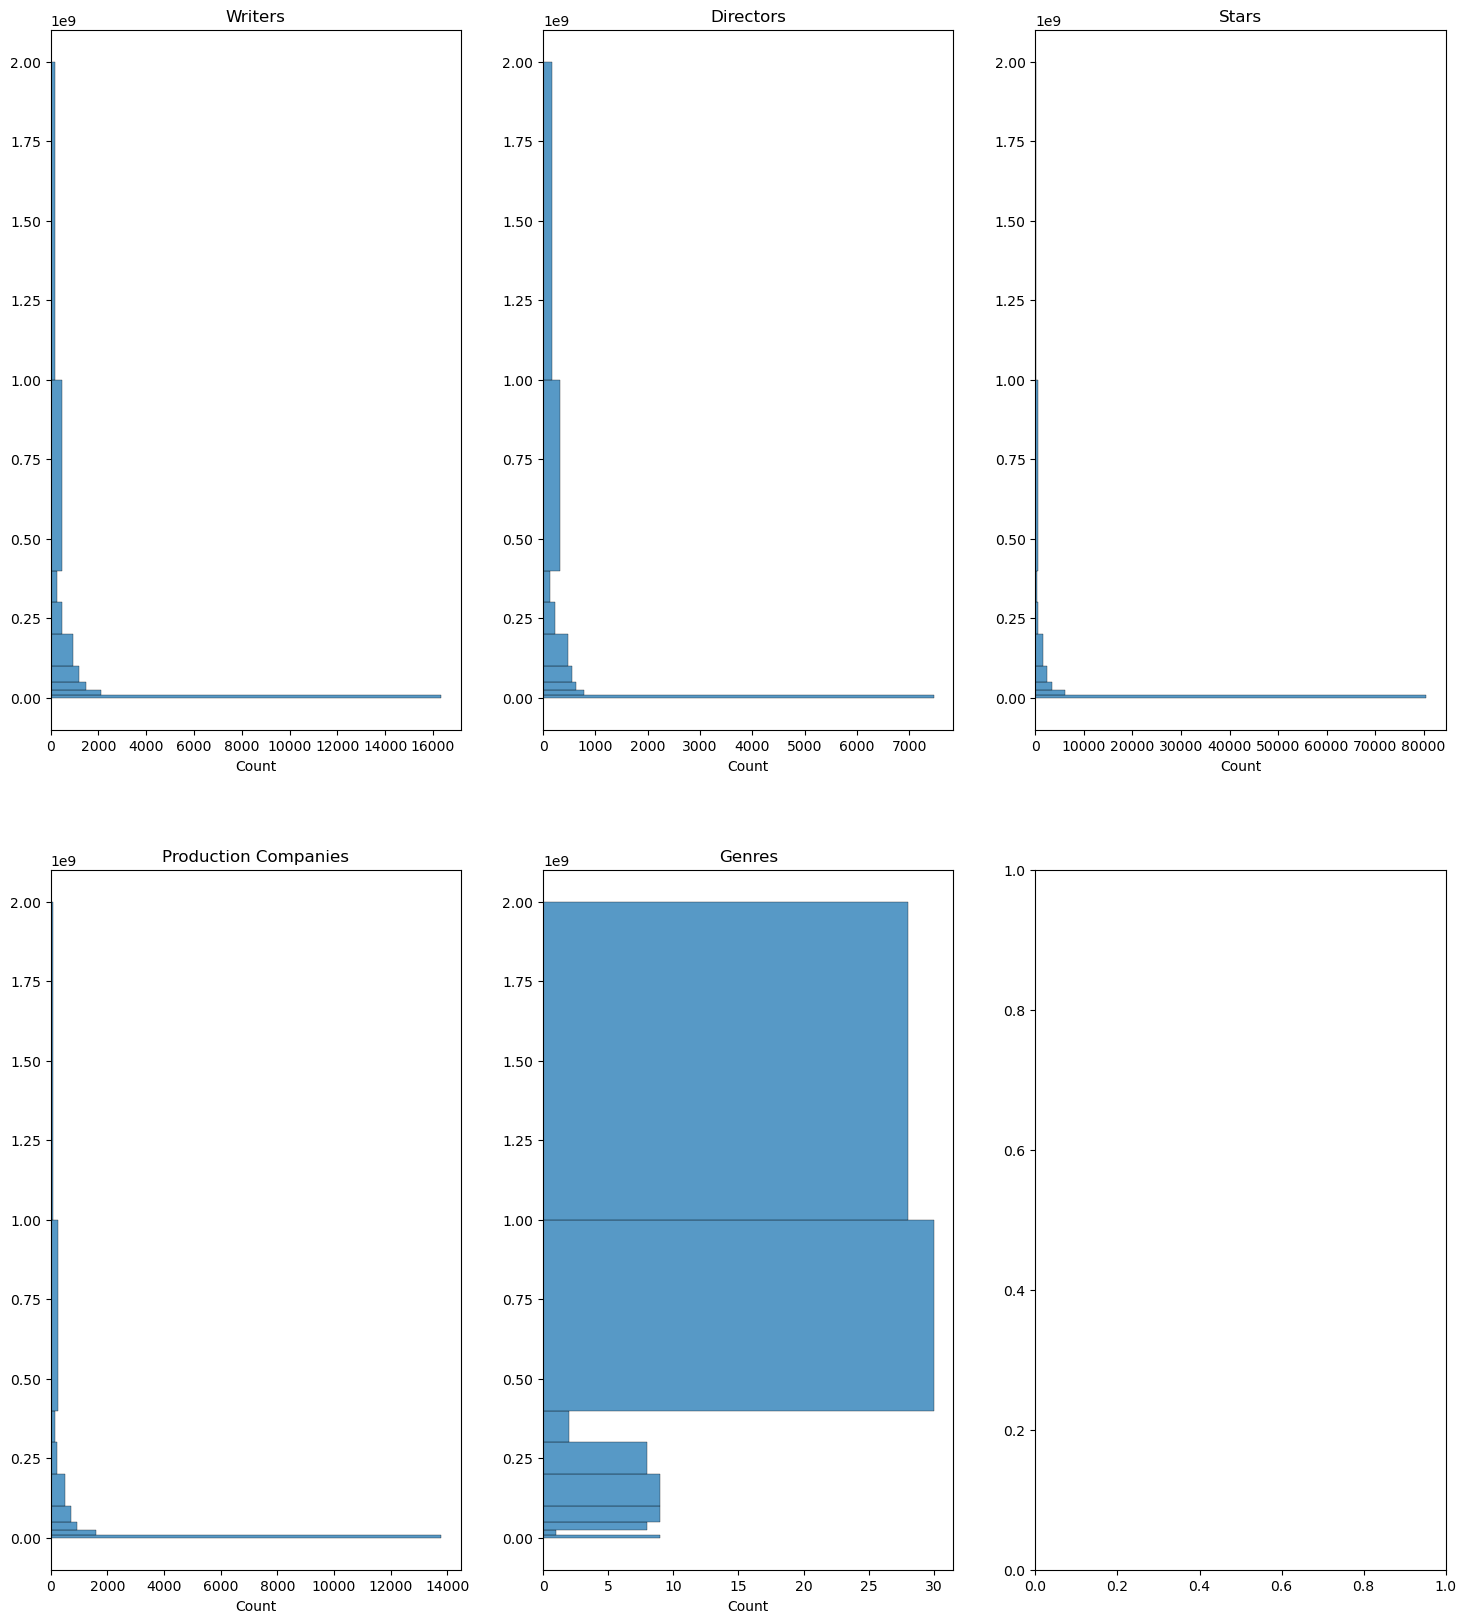

In [73]:
fig, axs = plt.subplots(ncols=3,nrows=2, figsize=(18, 20))
sns.histplot(y=wdict.values(), ax=axs[0,0],bins=[0, 1e7, 2.5e7,5e7,1e8,2e8,3e8,4e8,1e9,2e9])
sns.histplot(y=rdict.values(), ax=axs[0,1],bins=[0, 1e7, 2.5e7,5e7,1e8,2e8,3e8,4e8,1e9,2e9])
sns.histplot(y=sdict.values(), ax=axs[0,2],bins=[0, 1e7, 2.5e7,5e7,1e8,2e8,3e8,4e8,1e9,2e9])
sns.histplot(y=pdict.values(), ax=axs[1,0],bins=[0, 1e7, 2.5e7,5e7,1e8,2e8,3e8,4e8,1e9,2e9])
sns.histplot(y=gdict.values(), ax=axs[1,1],bins=[0, 1e7, 2.5e7,5e7,1e8,2e8,3e8,4e8,1e9,2e9])
axs[0,0].set_title('Writers')
axs[0,1].set_title('Directors')
axs[0,2].set_title('Stars')
axs[1,0].set_title('Production Companies')
axs[1,1].set_title('Genres')

In [92]:
for k in wad: wad[k] = wdict[k] / wad[k]
for k in rad: rad[k] = rdict[k] / rad[k]
for k in sad: sad[k] = sdict[k] / sad[k]
for k in pad: pad[k] = pdict[k] / pad[k]
for k in gad: gad[k] = gdict[k] / gad[k]

In [ ]:
#Sorted 
wdsort = {k: v for k, v in sorted(wdict.items(), key=lambda item: item[1],reverse=True)}
rdsort = {k: v for k, v in sorted(rdict.items(), key=lambda item: item[1],reverse=True)}
sdsort = {k: v for k, v in sorted(sdict.items(), key=lambda item: item[1],reverse=True)}
pdsort = {k: v for k, v in sorted(pdict.items(), key=lambda item: item[1],reverse=True)}
gdsort = {k: v for k, v in sorted(gdict.items(), key=lambda item: item[1],reverse=True)}


In [ ]:
#Top 100
wtop100 = dict(list(wdsort.items())[:100])
rtop100 = dict(list(rdsort.items())[:100])
stop100 = dict(list(sdsort.items())[:100])
ptop100 = dict(list(pdsort.items())[:100])
gtop100 = dict(list(gdsort.items())[:100])

Text(0.5, 1.0, 'Writers')

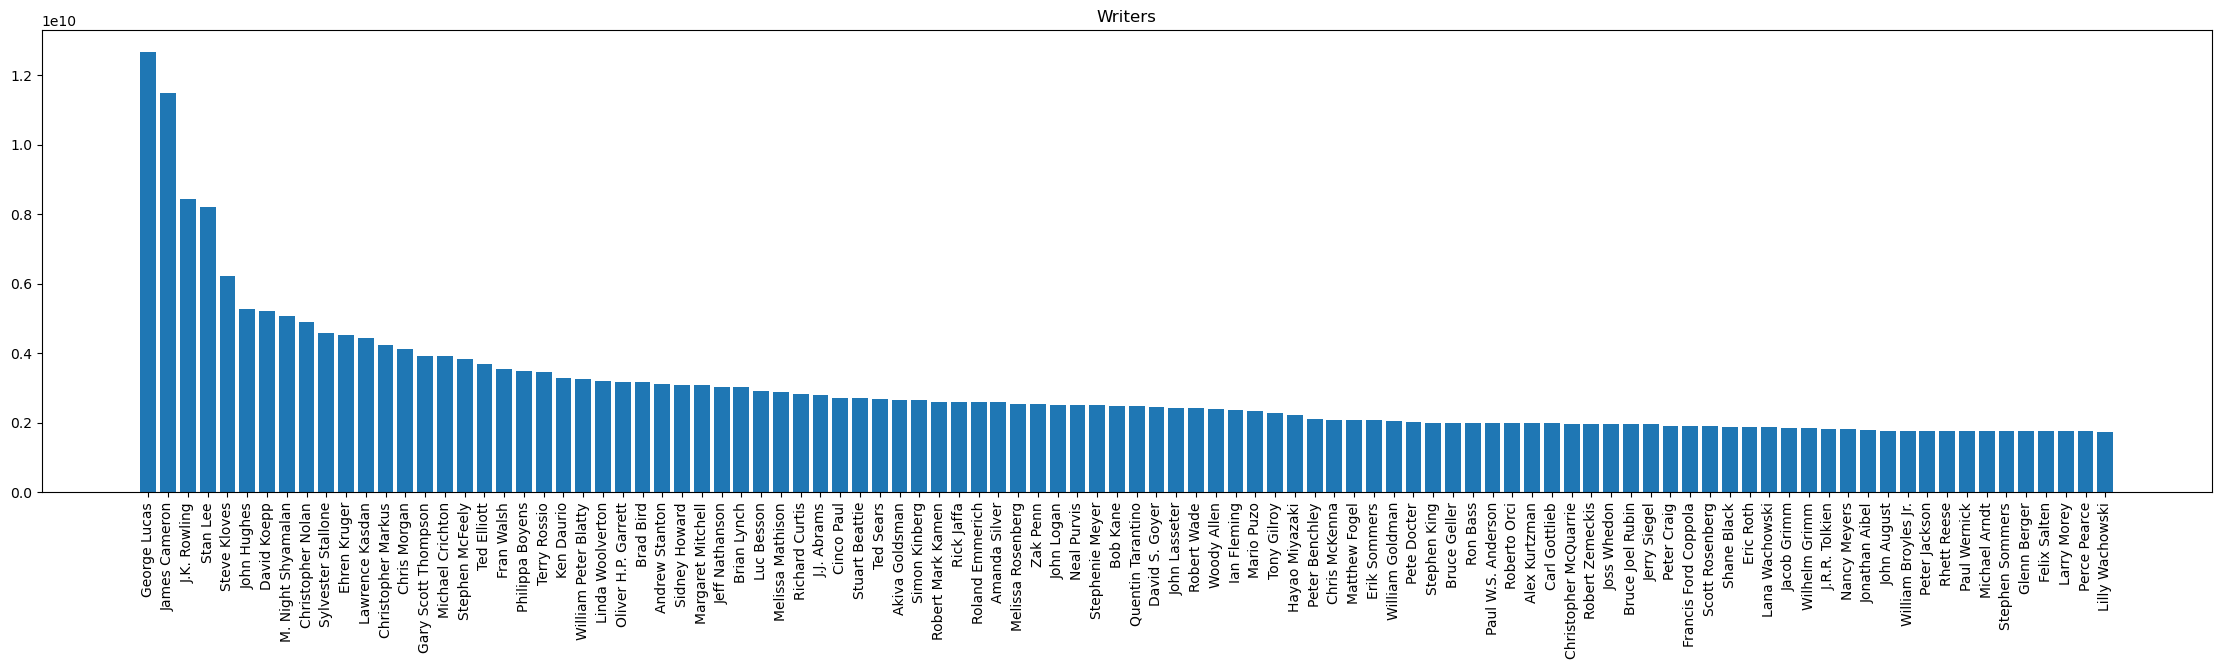

In [68]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=wtop100.keys(), height= wtop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Writers')

Text(0.5, 1.0, 'Directors')

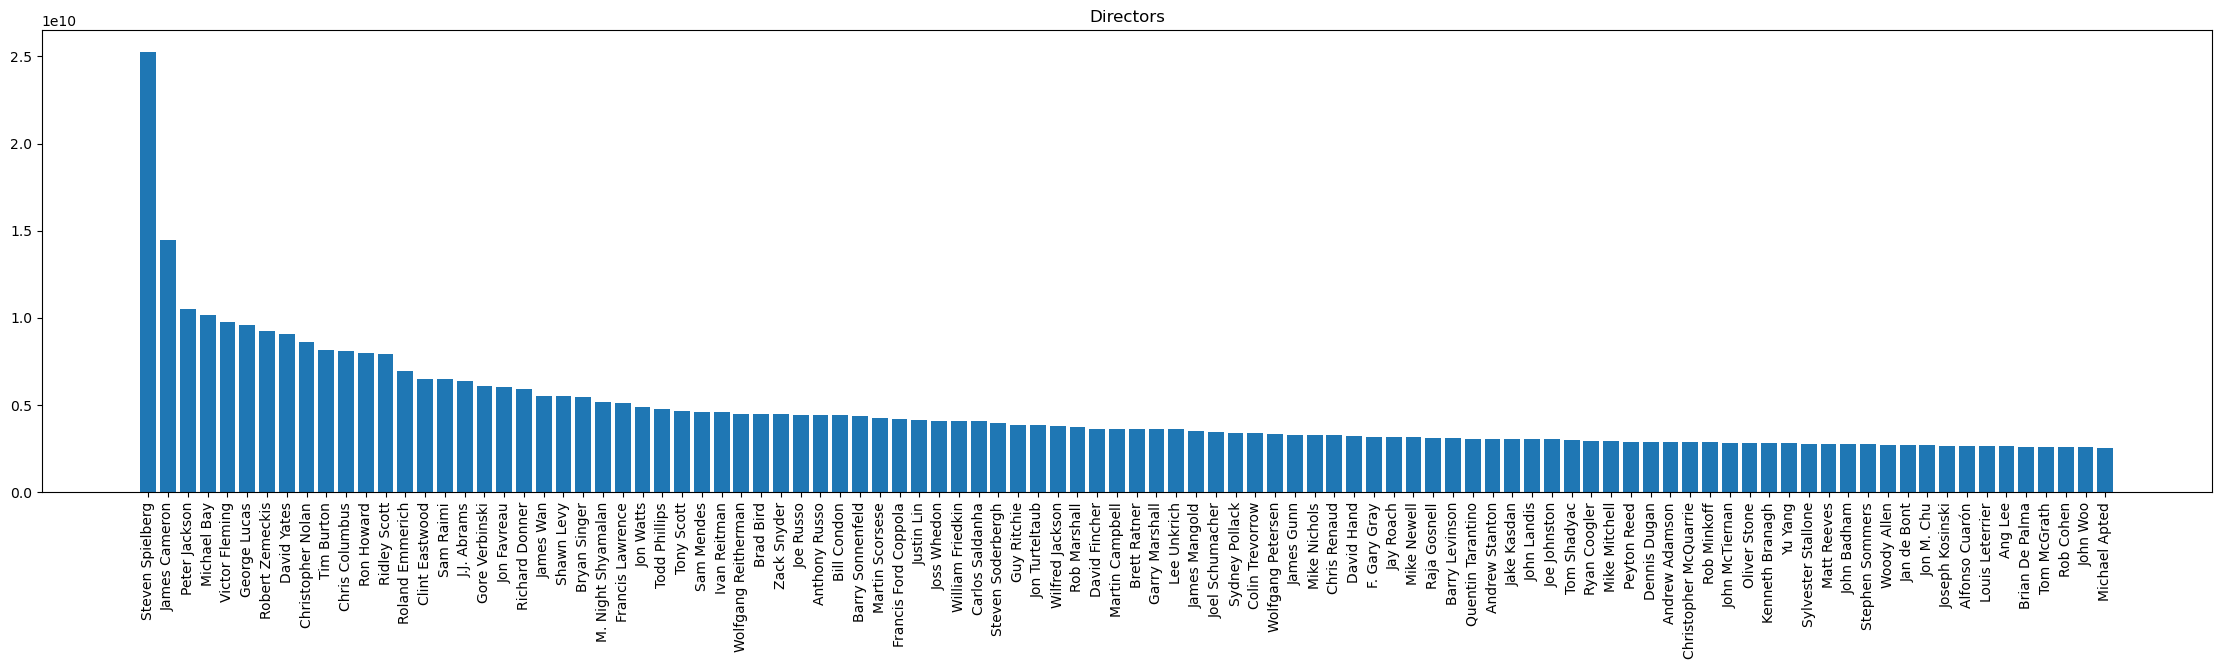

In [69]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=rtop100.keys(), height= rtop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Directors')

Text(0.5, 1.0, 'Stars')

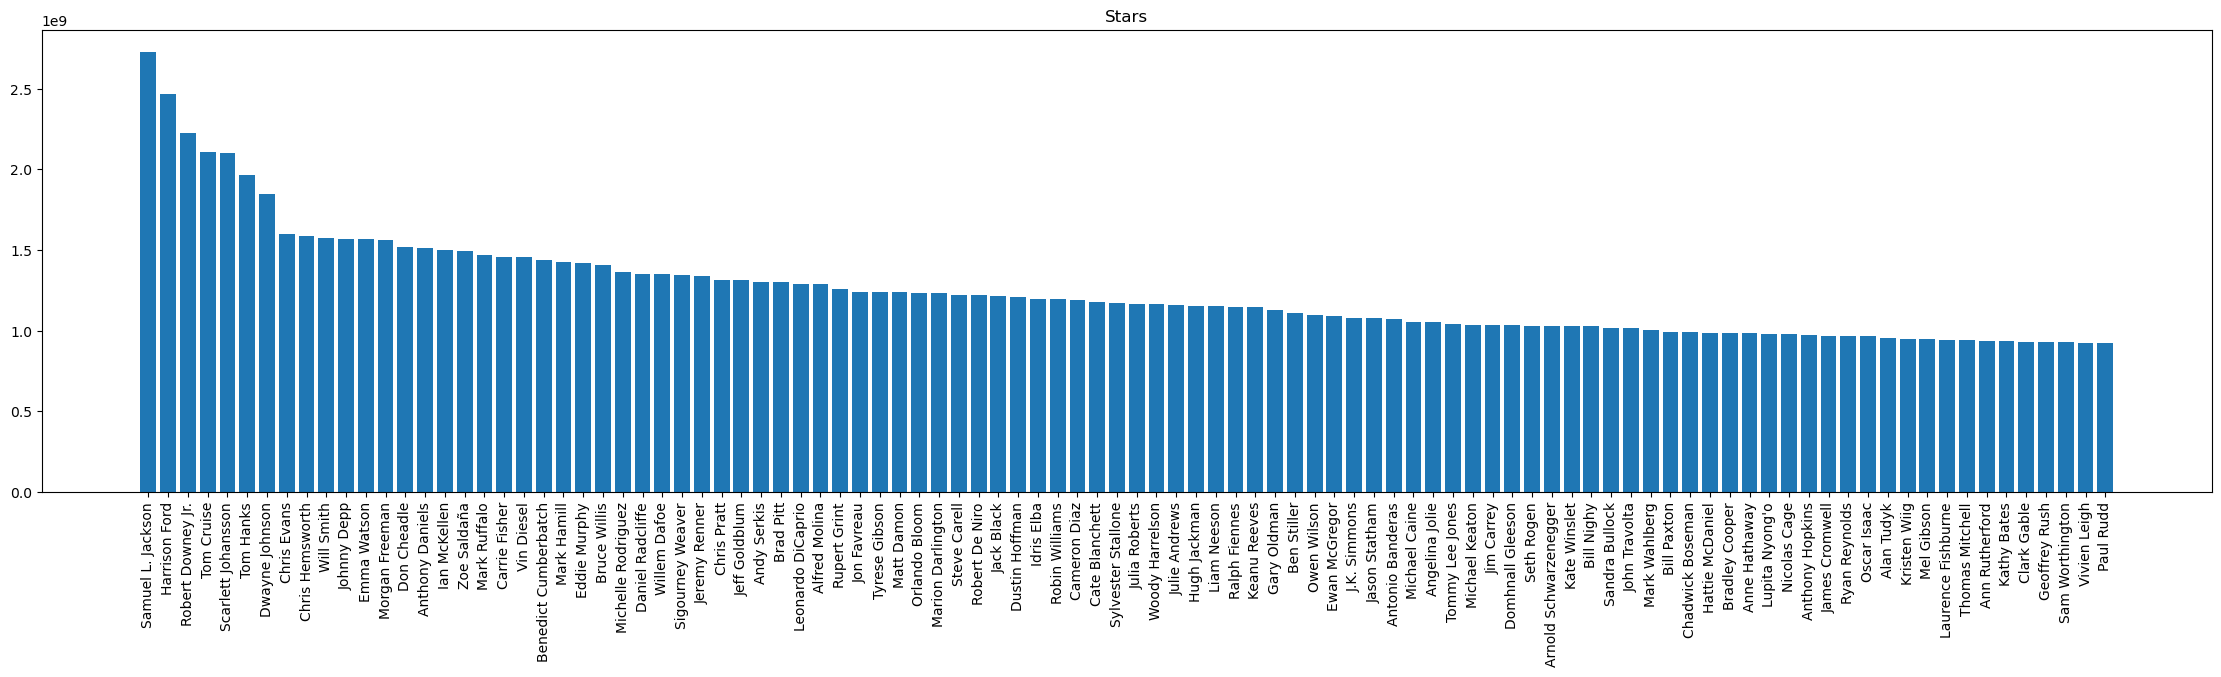

In [70]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=stop100.keys(), height= stop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Stars')

Text(0.5, 1.0, 'Production Companies')

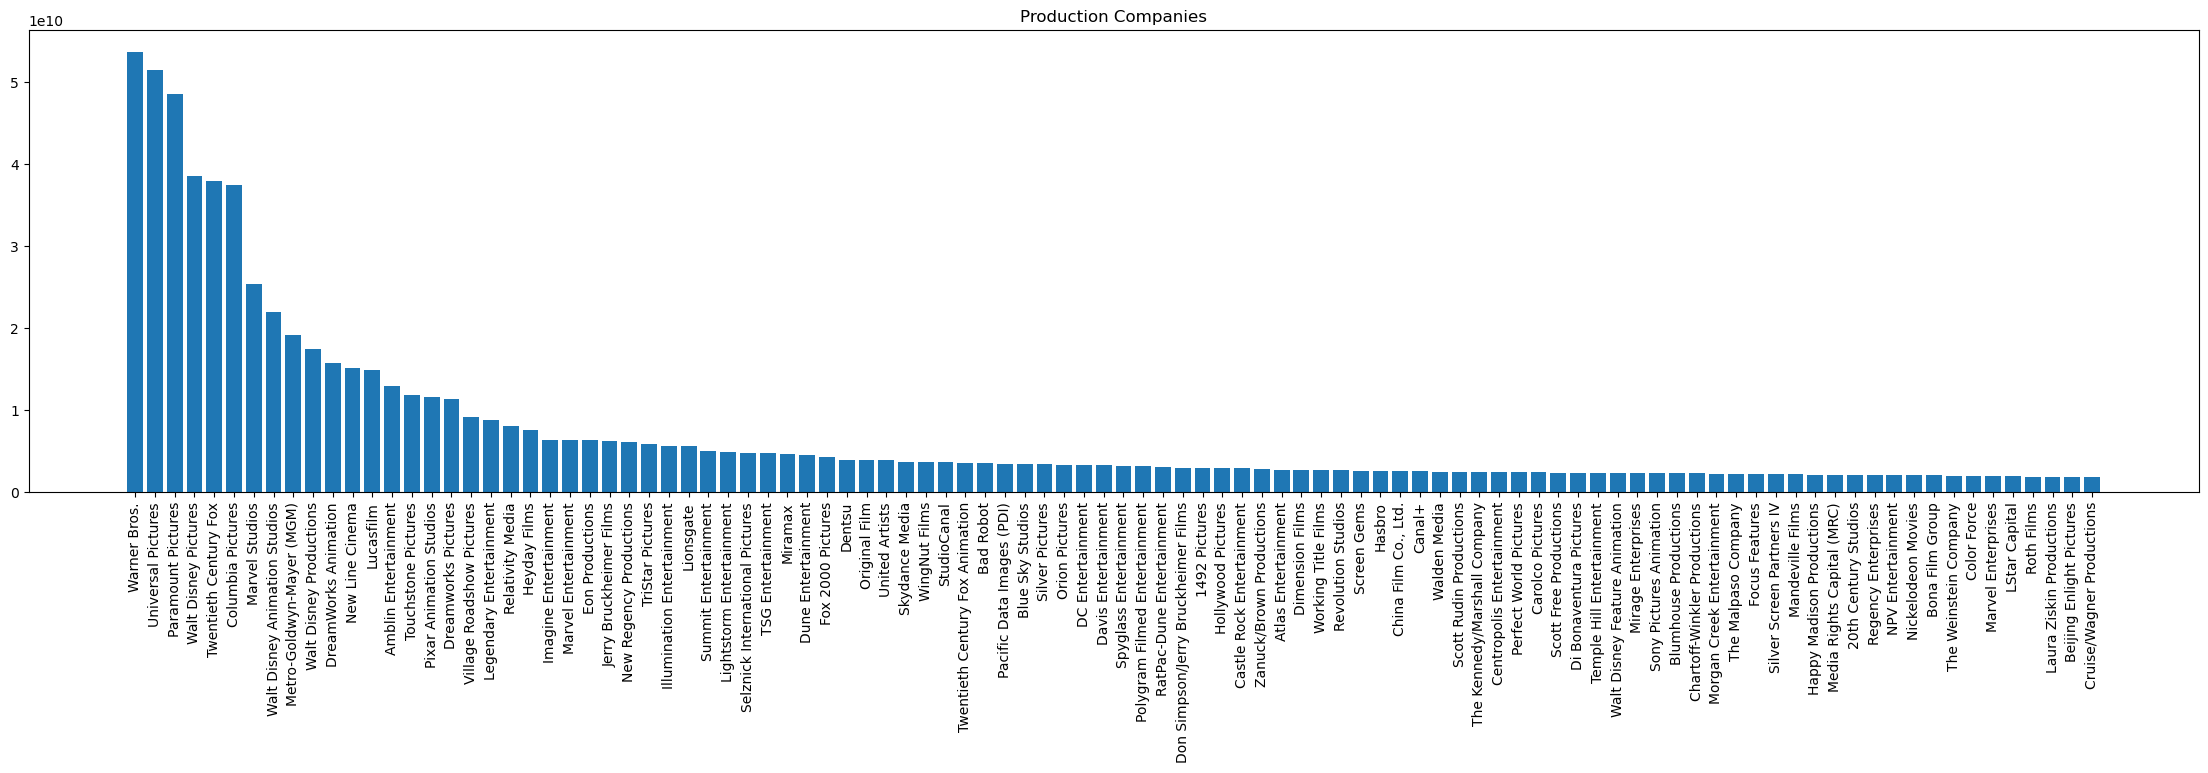

In [76]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=ptop100.keys(), height= ptop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Production Companies')

Text(0.5, 1.0, 'Genres')

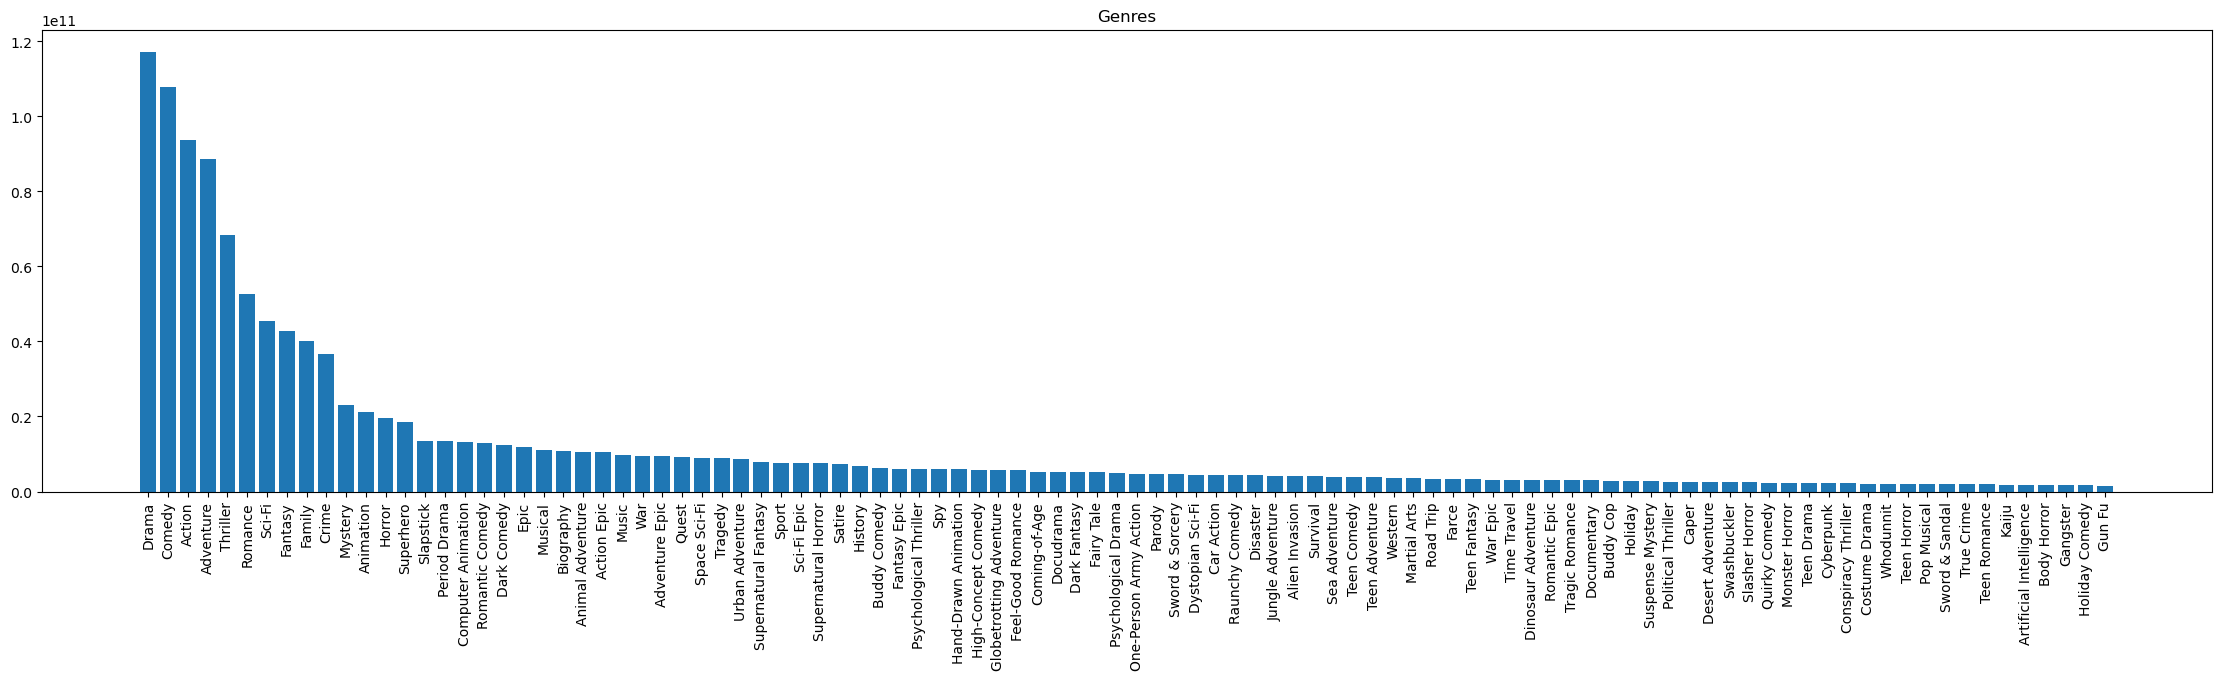

In [77]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=gtop100.keys(), height= gtop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Genres')

In [93]:
#Sorted averages 
wasort = {k: v for k, v in sorted(wad.items(), key=lambda item: item[1],reverse=True)}
rasort = {k: v for k, v in sorted(rad.items(), key=lambda item: item[1],reverse=True)}
sasort = {k: v for k, v in sorted(sad.items(), key=lambda item: item[1],reverse=True)}
pasort = {k: v for k, v in sorted(pad.items(), key=lambda item: item[1],reverse=True)}
gasort = {k: v for k, v in sorted(gad.items(), key=lambda item: item[1],reverse=True)}

In [94]:
#Top 100 averages
wadtop100 = dict(list(wasort.items())[:100])
radtop100 = dict(list(rasort.items())[:100])
sadtop100 = dict(list(sasort.items())[:100])
padtop100 = dict(list(pasort.items())[:100])
gadtop100 = dict(list(gasort.items())[:100])

Text(0.5, 1.0, 'Writers w/ Averages')

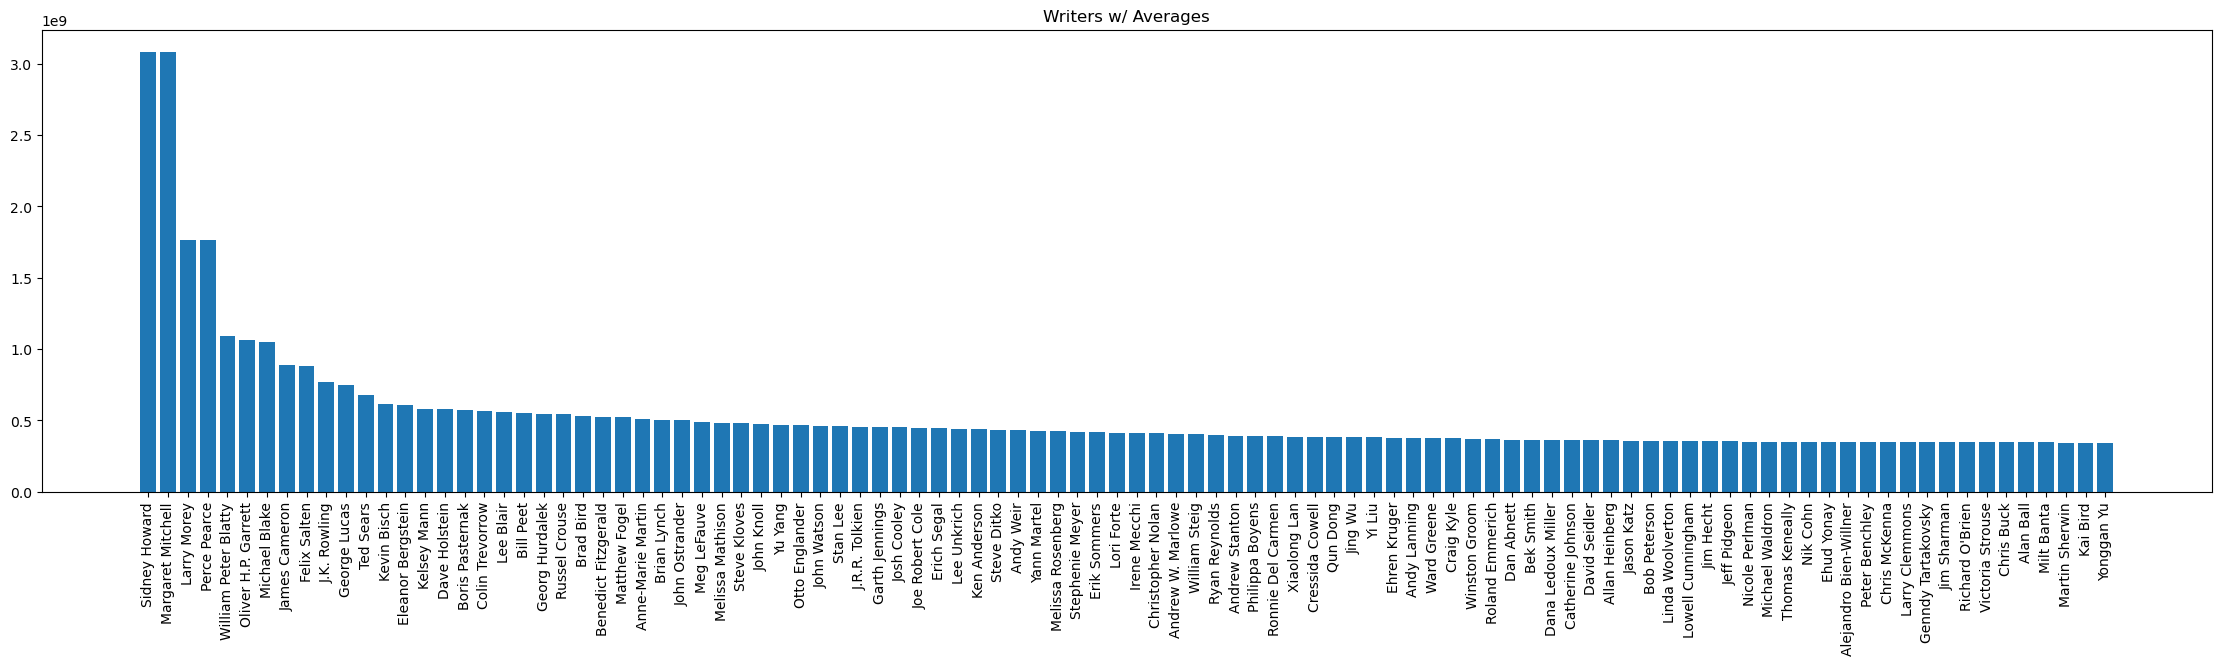

In [95]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=wadtop100.keys(), height= wadtop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Writers w/ Averages')

Text(0.5, 1.0, 'Directors w/ Averages')

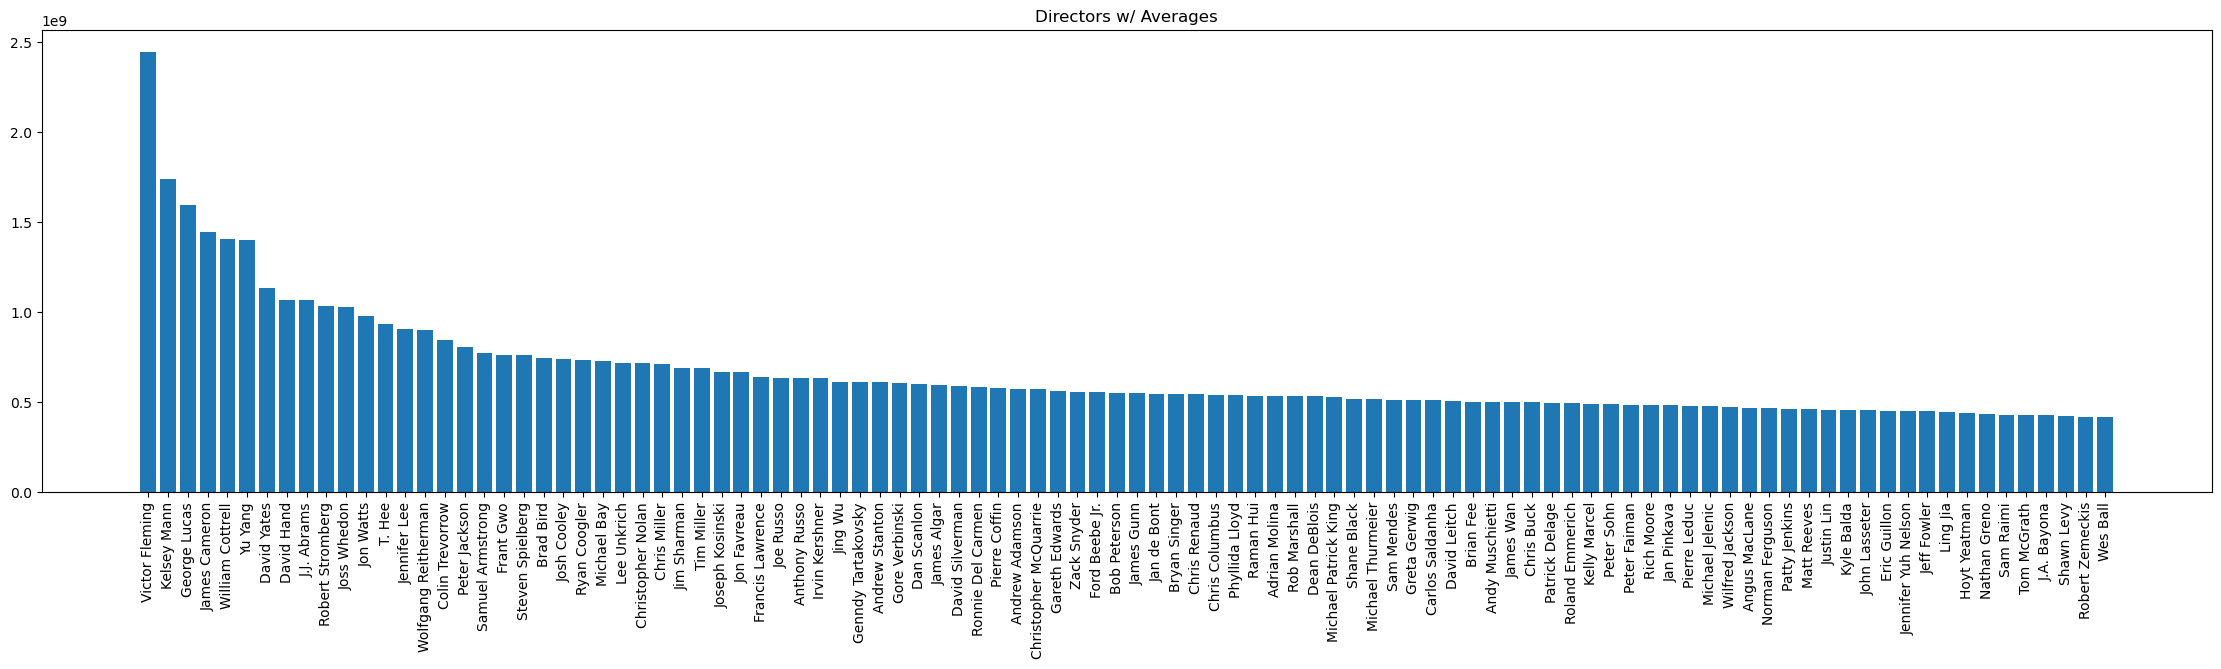

In [96]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=radtop100.keys(), height= radtop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Directors w/ Averages')

Text(0.5, 1.0, 'Stars w/ Averages')

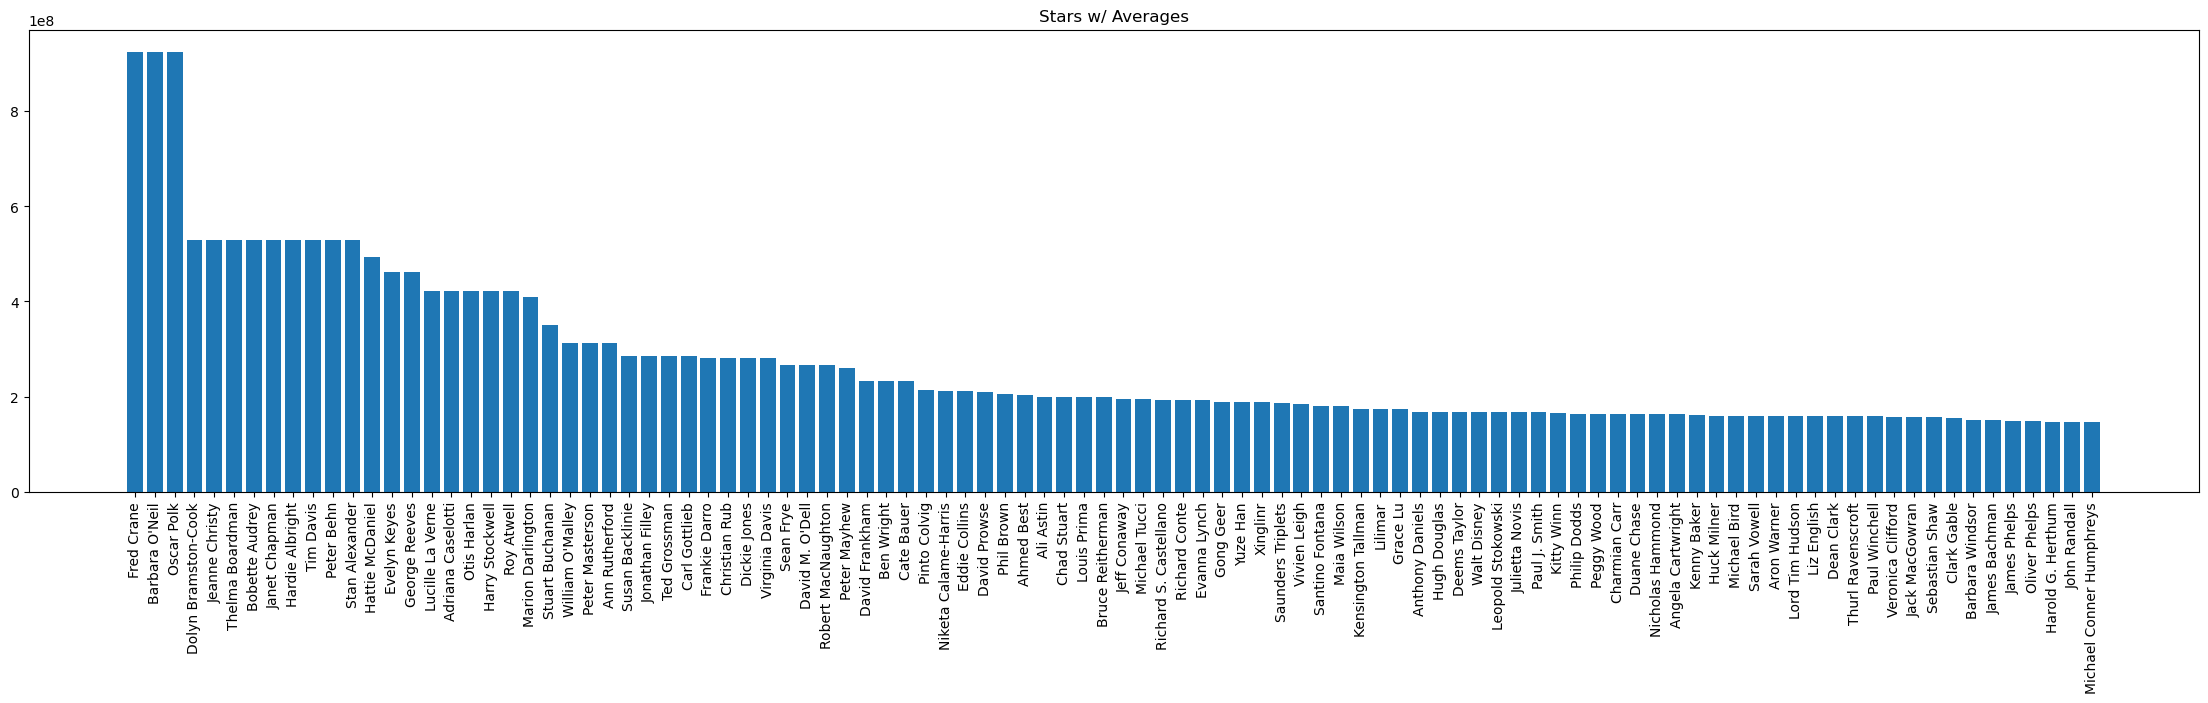

In [97]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=sadtop100.keys(), height= sadtop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Stars w/ Averages')

Text(0.5, 1.0, 'Production Companies w/ Averages')

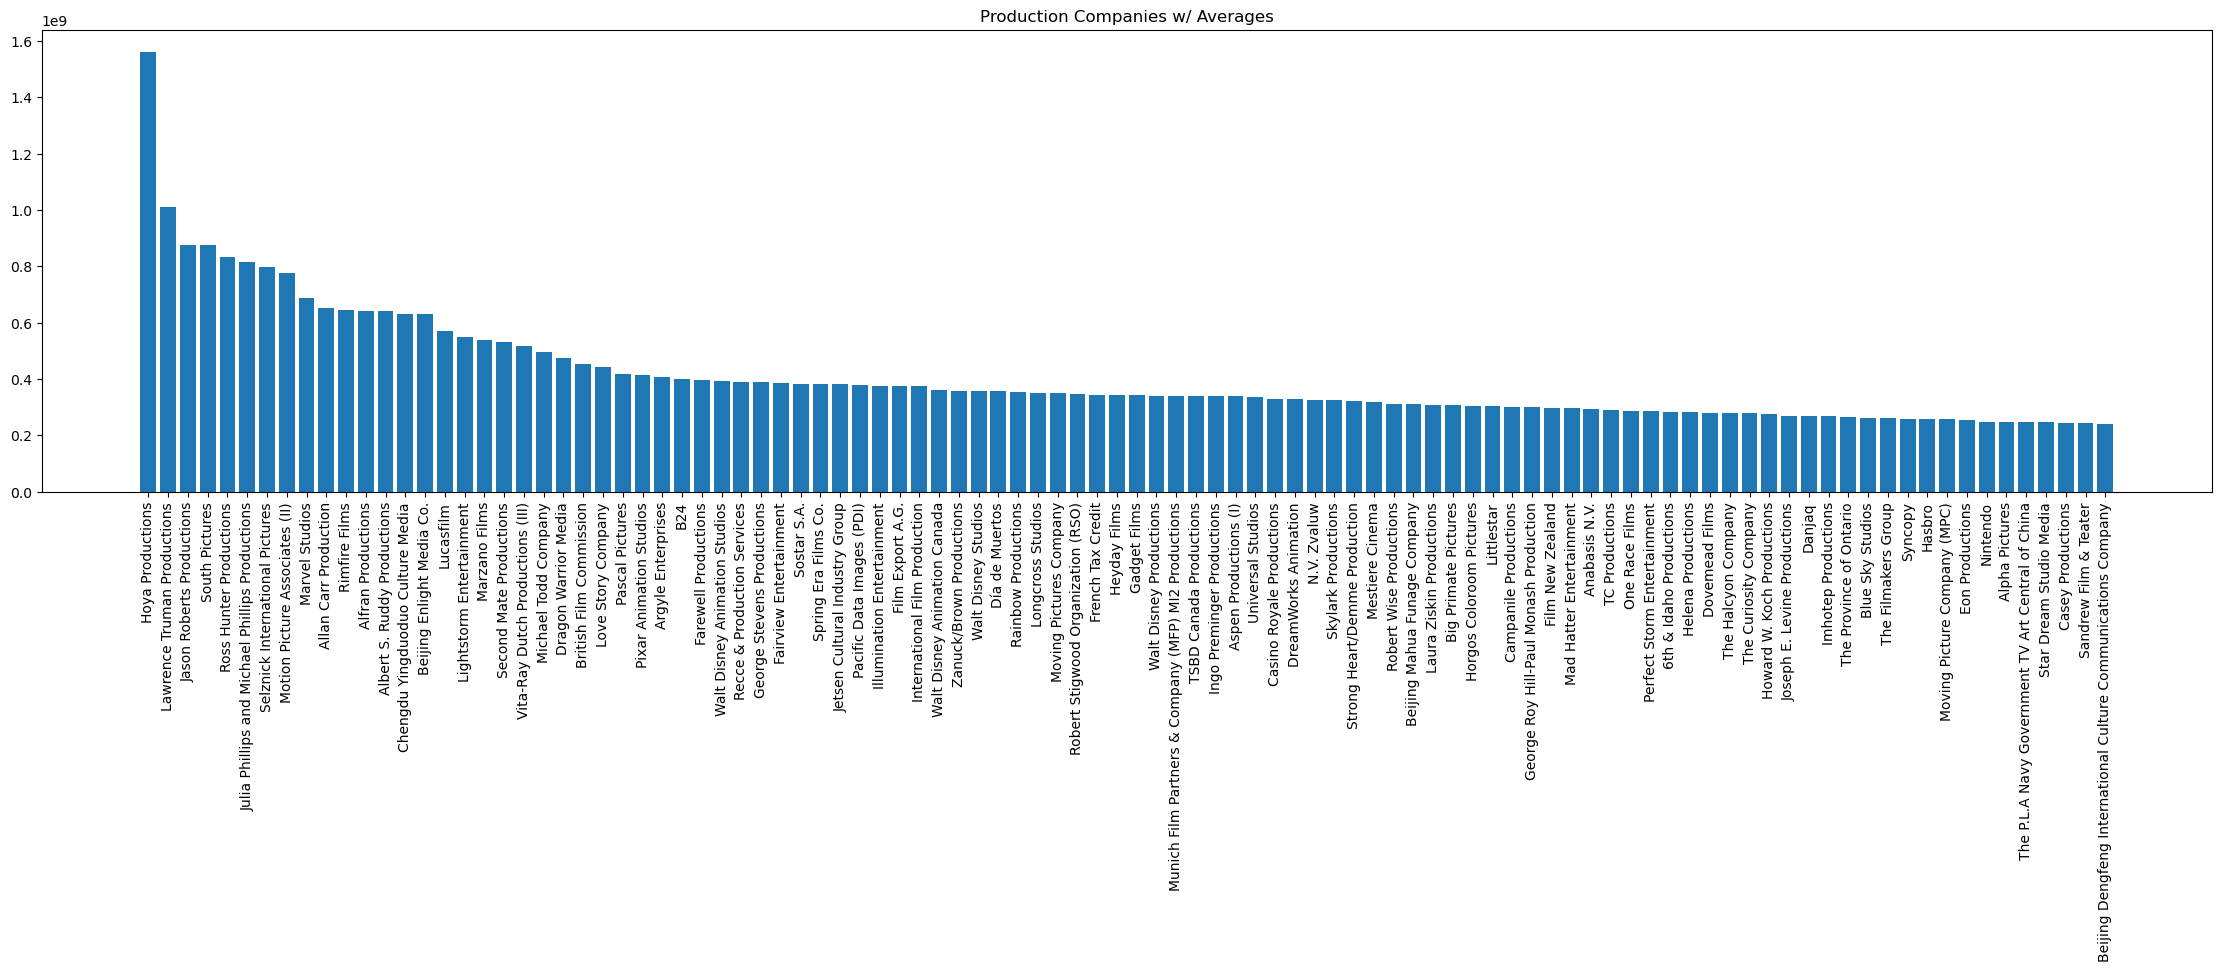

In [98]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=padtop100.keys(), height= padtop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Production Companies w/ Averages')

Text(0.5, 1.0, 'Genre w/ Averages')

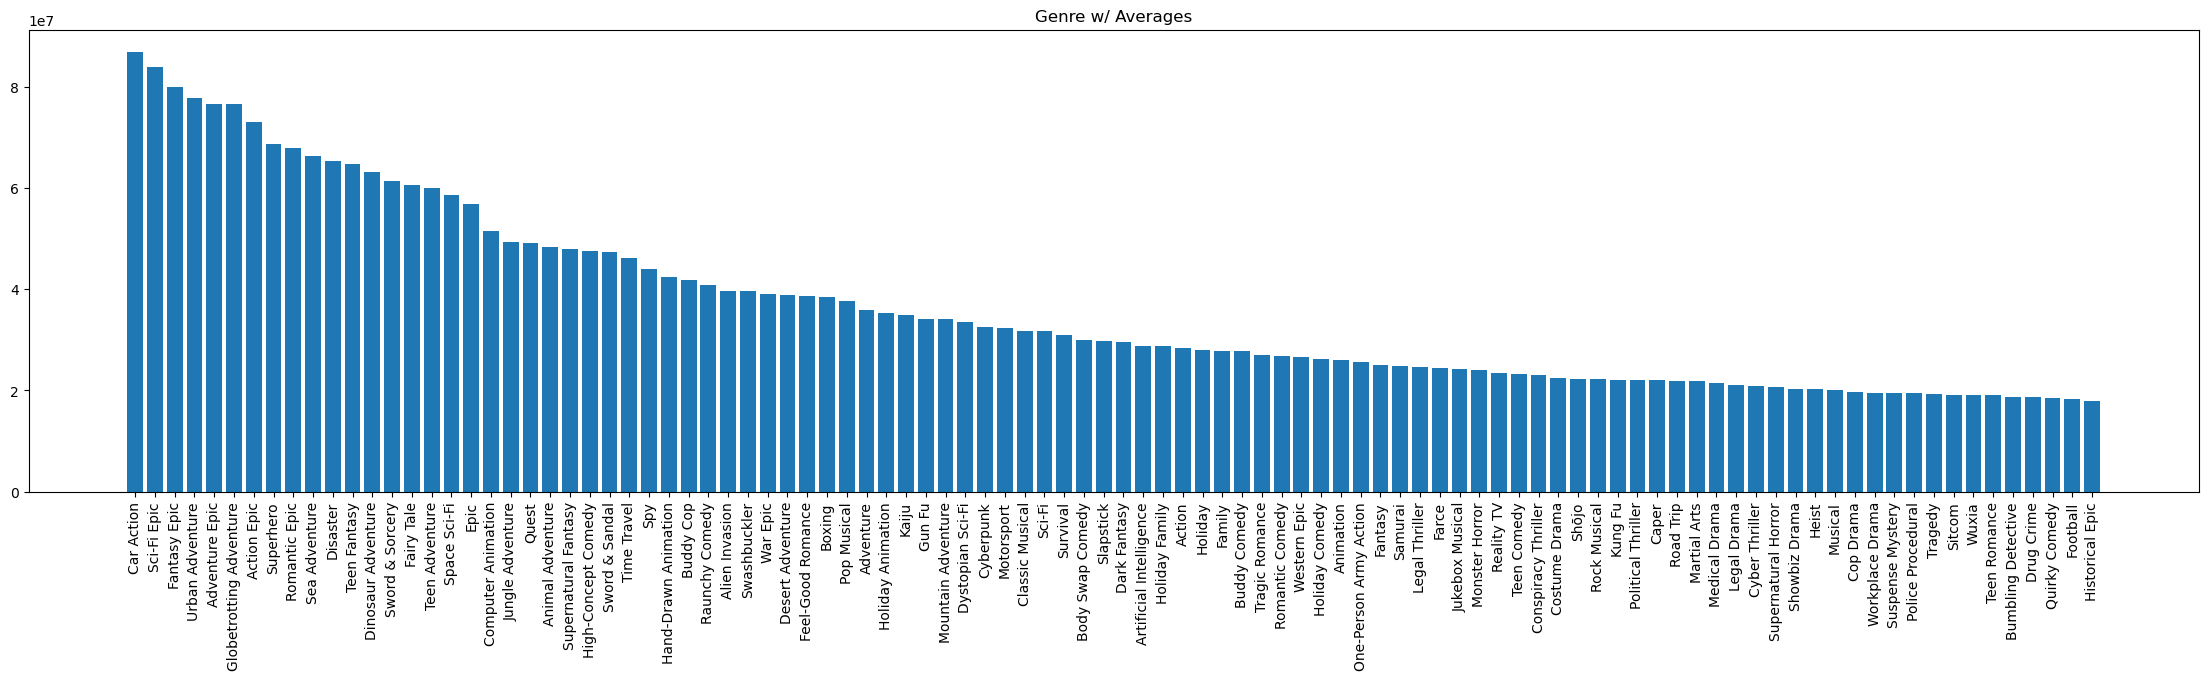

In [99]:
fig, ax = plt.subplots(figsize=(28,6))
plt.bar(x=gadtop100.keys(), height= gadtop100.values(),)
ax.tick_params(axis='x', rotation=90)
ax.set_title('Genre w/ Averages')